In [1]:
import sys 

print(sys.version_info)

sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0)


In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import os
import tarfile


In [3]:
def download_and_unarchive(url):
    if not os.path.exists("datasets"):
        os.mkdir("datasets")
    urllib.request.urlretrieve(url, "datasets/data.tgz")
    with tarfile.open("datasets/data.tgz") as archive:
        archive.extractall(path="datasets")

download_and_unarchive("https://homl.info/titanic.tgz")

/var/folders/d8/k55r2d1s5k78lrh9j8l3lfzw0000gn/T/ipykernel_67906/609056551.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(path="datasets")


In [4]:
titanic_data =  pd.read_csv("datasets/titanic/train.csv")
titanic_test = pd.read_csv("datasets/titanic/test.csv")
# print(titanic_data.head())
# print(titanic_data.info())
# print(titanic_data.describe())

In [5]:
titanic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
titanic_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
titanic_data.drop(columns=["PassengerId"], inplace=True)
titanic_test.drop(columns=["PassengerId"], inplace=True)

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

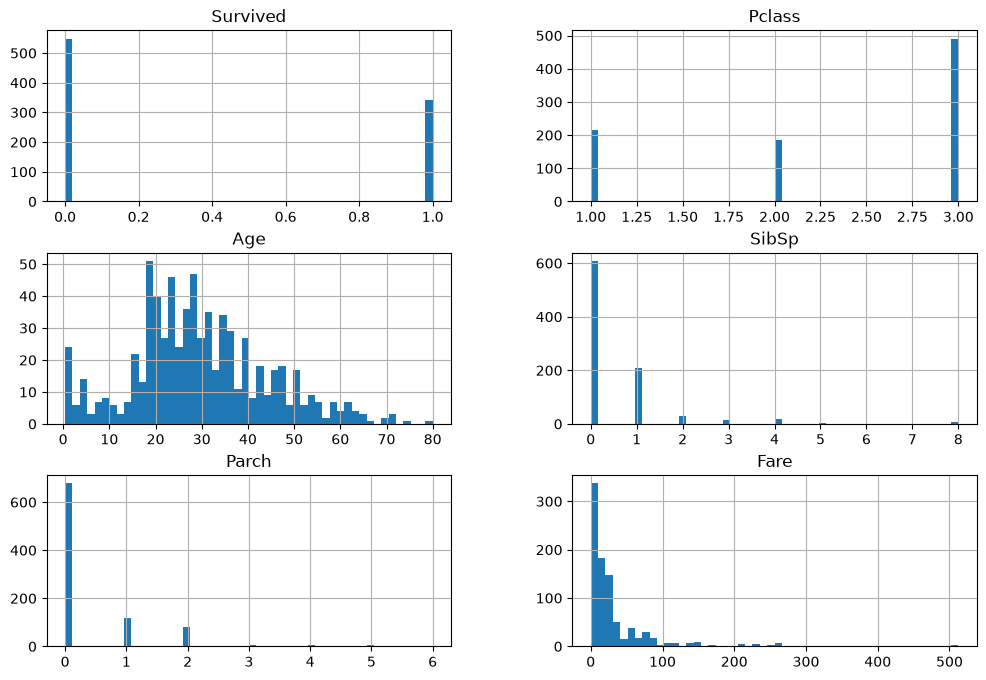

In [7]:
titanic_data.hist(bins=50, figsize=(12,8))

In [7]:
y = titanic_data.Survived

In [8]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

array([[<Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass'>,
        <Axes: xlabel='Parch', ylabel='Pclass'>,
        <Axes: xlabel='Fare', ylabel='Pclass'>],
       [<Axes: xlabel='Pclass', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Parch', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>],
       [<Axes: xlabel='Pclass', ylabel='SibSp'>,
        <Axes: xlabel='Age', ylabel='SibSp'>,
        <Axes: xlabel='SibSp', ylabel='SibSp'>,
        <Axes: xlabel='Parch', ylabel='SibSp'>,
        <Axes: xlabel='Fare', ylabel='SibSp'>],
       [<Axes: xlabel='Pclass', ylabel='Parch'>,
        <Axes: xlabel='Age', ylabel='Parch'>,
        <Axes: xlabel='SibSp', ylabel='Parch'>,
        <Axes: xlabel='Parch', ylabel='Parch'>,
        <Axes: xlabel='Fare', ylabel='Parch'>],
       [<Axes: xlabel='Pclass', ylabel='Fare'>,
 

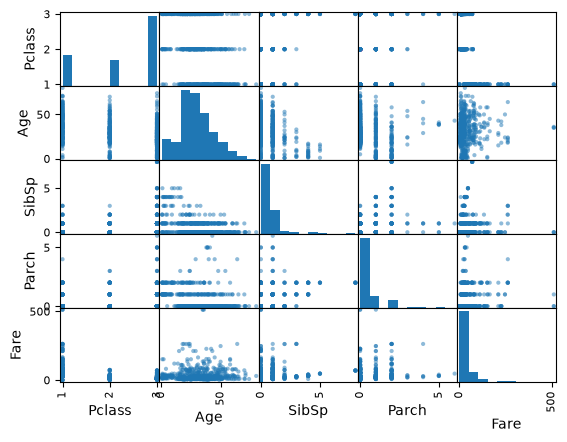

In [9]:
from pandas.plotting import scatter_matrix

scatter_matrix(titanic_data[['Pclass', 'Age', 'SibSp', 'Parch',
       'Fare']])


<Axes: xlabel='Sex'>

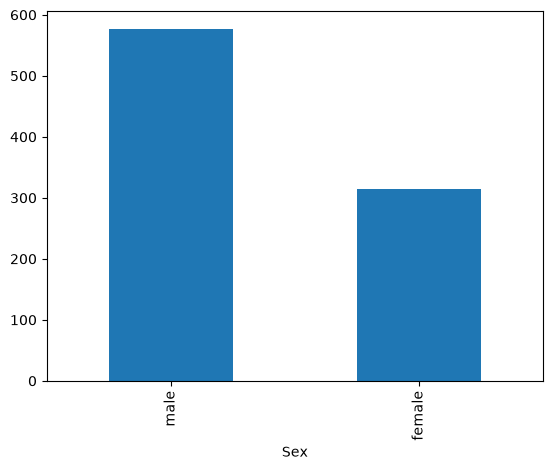

In [10]:
titanic_data.Sex.value_counts().plot(kind='bar')

In [ ]:
titanic_data["Name"].str.extract(r"([A-Za-z]+)\.")

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("inputer", SimpleImputer(strategy="median", missing_values=np.nan)),
    ("scaller", StandardScaler())
])

In [13]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

cat_pipeline = Pipeline([("ordinal", OrdinalEncoder()),
                         ("imputer", SimpleImputer(strategy="most_frequent")),
                         ("cat_encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))])

In [14]:
titanic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [15]:
from sklearn.compose import ColumnTransformer

cat = ["Sex","Embarked"]
num = ["Pclass", "Age","SibSp","Parch","Fare"]

processed_pipeline = ColumnTransformer(
    [("num", num_pipeline, num),
    ("cat", cat_pipeline, cat)
    ]
)

In [16]:
titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [17]:
X_train=processed_pipeline.fit_transform(titanic_data)

In [18]:
X_test = processed_pipeline.transform(titanic_test)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
from sklearn.model_selection import cross_val_predict, cross_val_score

predictions = cross_val_predict(model,X_train, y, cv=10)
scores = cross_val_score(model, X_train,y , cv=10)

print(scores.mean())

0.8126591760299625


In [21]:
test_predictions = model.predict(X_test)

In [22]:
submission = pd.DataFrame({
    "PassengerId": titanic_test["PassengerId"],
    "Survived": test_predictions
})
submission.to_csv("submission.csv", index=False)

In [23]:
from sklearn.metrics import precision_score, recall_score

precision_score = precision_score(predictions, y)
recall_score= recall_score(predictions,y)

print(precision_score, recall_score)

0.7368421052631579 0.7682926829268293


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predictions)

print(cm)

[[473  76]
 [ 90 252]]


In [25]:
y_probas = cross_val_predict(model, X_train, y, cv=10 , method="predict_proba")
scores = y_probas[:, 1]

In [26]:
print(scores)

[0.18233333 1.         0.54       1.         0.         0.05171368
 0.07       0.56       0.56       0.93       0.74       0.8
 0.12516667 0.01       0.64       0.82       0.18       0.
 0.91       0.86       0.03       0.02       0.63       0.09
 0.17       0.02       0.         0.52       0.98       0.
 0.56666667 0.98       0.81456602 0.3        0.73       0.7
 0.         0.02       0.63       0.36       0.21       0.91
 0.12       0.84       0.48       0.         0.05       0.81456602
 0.48       0.61       0.12       0.64       0.97       1.
 0.21       0.09       0.90333333 0.         0.93       0.02
 0.52       0.97       0.49       0.27       0.23       0.76
 0.98       0.5575     0.27       0.17       0.1215     0.19
 0.08333333 0.28       0.8675119  0.025      0.         0.
 0.824      0.5        0.01       0.06       0.85509563 0.01
 0.921      0.44       0.08       0.         0.81       0.
 0.01       0.03       0.56       0.16       0.02       0.
 0.26       0.5        0.9

In [27]:
from sklearn.metrics import precision_recall_curve
precision, recalls, thresholds = precision_recall_curve(y,scores)

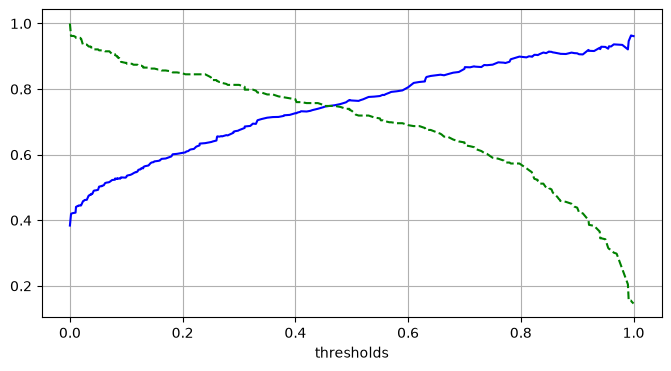

In [28]:
plt.figure(figsize=(8,4))
plt.plot(thresholds, precision[:-1], "b-", label="Precision")
plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
plt.xlabel("thresholds")
plt.grid(True)
plt.show()

In [29]:
from sklearn.metrics import roc_curve 

fpr, tpr, thresholds = roc_curve(y, scores)

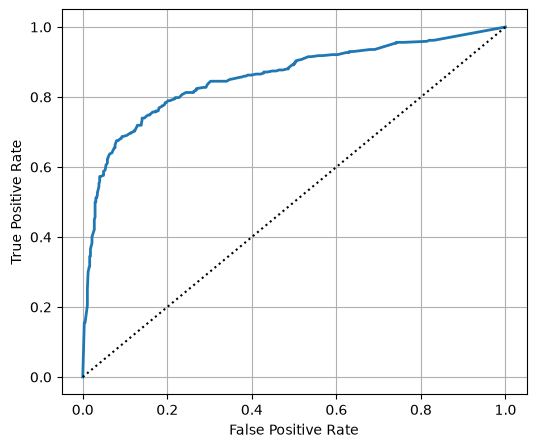

In [34]:
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr, linewidth=2, label="ROC curve")
plt.plot([0,1], [0,1], "k:", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()

In [35]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, scores)

0.8551992458377272